# Сети для детекции текста на изображении (DB-Net, EAST, CRAFT)


Долгое время задачу OCR (оптическое распознавание символов) пытались решить  "в лоб": классические системы (вроде раннего Tesseract) брали картинку, пытались найти на ней строчки, разбить их на буквы и сразу распознать. Это отлично работало для сканов документов (черный текст на белом фоне), но полностью ломалось в на реальных фотографиях (Scene Text)  на вывесках, этикетках, номерах машин и т.д

Поэтому современный пайплайн OCR разделили на два независимых этапа:

**Text Detection (Детекция)** — нейросеть находит, где на картинке есть текст, и выделяет его рамками (bounding boxes).

**Text Recognition (Распознавание)** — другая нейросеть распознает текст внутри этих рамок.

В этой лекции мы разбираем первый этап и основные сети, которые используются:

*   [**EAST**](https://arxiv.org/abs/1704.03155) (2017 год): Революционная для своего времени сеть. До неё текст искали сложными многоступенчатыми методами. EAST предложила делать это за один проход (One-Stage). Она быстрая, но слаба перед сильно изогнутым текстом.
*   [**CRAFT**](https://arxiv.org/abs/1904.01941) (2019 год): Сеть, которая перевернула подход. Вместо поиска целых слов или строк, она ищет отдельные символы и связи между ними. Идеальна для сложных шрифтов и изогнутого текста.
*   [**DB-Net**](https://arxiv.org/abs/1911.08947) (2019–2020 годы): Современный индустриальный стандарт. Быстрая и точная сеть, которая умеет идеально находить границы текста.

*  [**DB++**](https://arxiv.org/abs/2202.10304) (2022 год): Улучшенная версия. Добавили механизм ASF (Adaptive Scale Fusion), который объединяет признаки разных масштабов более умно. Она гораздо лучше справляется с многомасштабным текстом (когда на одном фото и гигантская вывеска, и мелкий шрифт внизу).

## EAST (Efficient and Accurate Scene Text detector)

<center><img src ="https://ml.gan4x4.ru/wb/ocr/east.png" width="700"></center>

<center><em>Source: <a href="https://arxiv.org/abs/1704.03155">Efficient and Accurate Scene Text detector</a></em></center>

**Интуиция**. Представьте, что вы смотрите на фотографию и для каждой точки изображения отвечаете на два вопроса: "здесь вообще есть текст?" и "если есть, где заканчивается это слово?". Именно так работает EAST он обрабатывает изображение за один проход и отвечает на оба вопроса одновременно для каждого пикселя карты.

**Архитектура**. EAST состоит из трех частей. Feature Extractor, обычно PVANet или ResNet, последовательно сжимает изображение, извлекая признаки на разных масштабах. Feature Merger работает как в U-Net берет признаки с разных уровней и объединяет их снизу вверх, чтобы сеть одновременно "видела" и мелкие буквы, и крупные заголовки. Output Layer выдает два тензора: score map и geometry map.

* **Score map** это карта уверенности, число от 0 до 1 для каждого пикселя, отвечающее на вопрос "здесь текст?".

* **Geometry map** в формате RBOX содержит для каждого пикселя пять чисел: расстояния до верхней, правой, нижней и левой сторон ближайшего текстового бокса, плюс угол поворота. Из этих пяти чисел можно однозначно восстановить повернутый прямоугольник вокруг слова.

Финальный шаг это NMS по повернутым прямоугольникам, который убирает дубли.

**Как обучали**. Используется multi-task loss сеть одновременно учится решать задачу классификации (текст / не текст) и задачу регрессии (точные координаты и угол по RBOX). Оба лосса оптимизируются вместе, что заставляет модель находить баланс между "найти все слова" и "точно обвести каждое".

**Важный нюанс.** EAST принципиально однопроходный, он не умеет итеративно уточнять свои предсказания. Это делает его быстрым, но чувствительным к качеству разметки если в обучающем датасете рамки вокруг слов были размечены неточно или под разными углами, сеть воспроизведет эту неточность. Кроме того, EAST плохо справляется с очень длинными строками, широкий текстовый регион плохо вписывается в RBOX представление, и сеть вынуждена дробить его на несколько боксов.

### Пример работы

In [ ]:
!wget --no-check-certificate "https://ml.gan4x4.ru/wb/cv/images/cost_badge_1.jpg"

--2026-04-03 15:07:01--  https://ml.gan4x4.ru/wb/cv/images/cost_badge_1.jpg
Resolving ml.gan4x4.ru (ml.gan4x4.ru)... 212.24.105.216
Connecting to ml.gan4x4.ru (ml.gan4x4.ru)|212.24.105.216|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 114277 (112K) [image/jpeg]
Saving to: ‘cost_badge_1.jpg.2’

cost_badge_1.jpg.2  100%[===================>] 111.60K   347KB/s    in 0.3s    

2026-04-03 15:07:02 (347 KB/s) - ‘cost_badge_1.jpg.2’ saved [114277/114277]



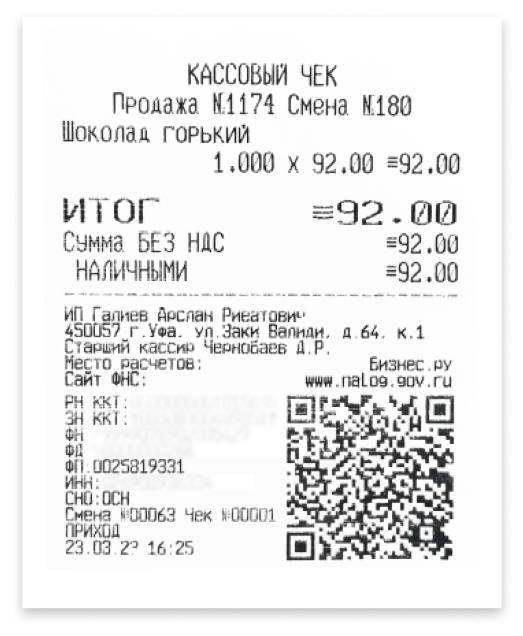

In [ ]:
import cv2
import matplotlib.pyplot as plt

image_path = 'cost_badge_1.jpg'
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(image_rgb)

plt.axis('off')
plt.show()

Модель загружена
Изображение: 368×450
Найдено регионов: 38
Пример бокса pts: [[ 45 177]
 [ 45 158]
 [ 91 158]
 [ 91 177]]
orig: 368×450, INP: 320×320, ratio: 1.150×1.406


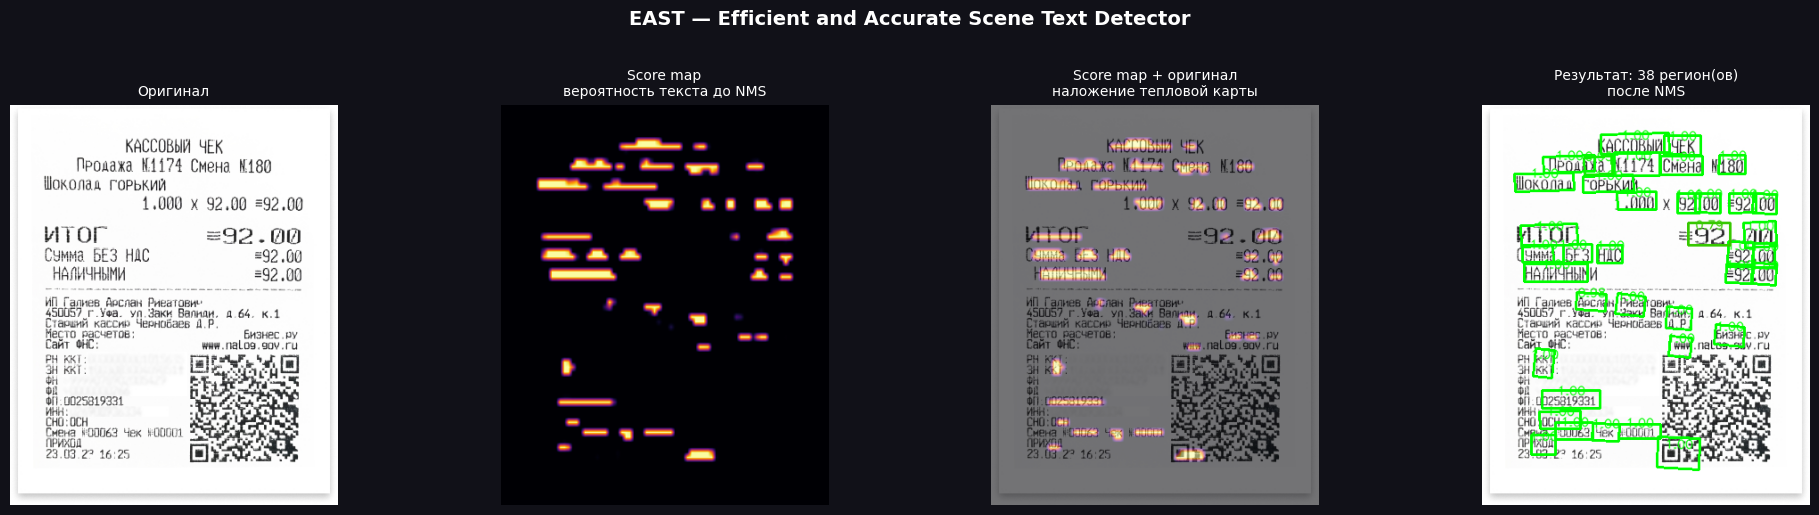

Сохранено: east_result.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from pathlib import Path

MODEL_URL  = "https://github.com/oyyd/frozen_east_text_detection.pb/raw/master/frozen_east_text_detection.pb"
MODEL_PATH = Path("frozen_east_text_detection.pb")

if not MODEL_PATH.exists():
    print("⬇  Загружаем EAST...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

OUTPUT_LAYERS = [
    "feature_fusion/Conv_7/Sigmoid",   # score map  — вероятность текста (1,1,H/4,W/4)
    "feature_fusion/concat_3",         # geometry   — RBOX: 4 расстояния + угол (1,5,H/4,W/4)
]

net = cv2.dnn.readNet(str(MODEL_PATH))
print("Модель загружена")

IMAGE_PATH = "/content/cost_badge_1.jpg"
image_bgr  = cv2.imread(IMAGE_PATH)
print(f"Изображение: {image_bgr.shape[1]}×{image_bgr.shape[0]}")


#  Параметры
INP_W        = 320   # кратно 32: чем больше — тем медленнее, но лучше качество
INP_H        = 320
SCORE_THRESH = 0.3
NMS_THRESH   = 0.2

orig_h, orig_w = image_bgr.shape[:2]
# scores/geometry имеют размер INP/4 (stride=4)
# координаты декодируются в пространстве карты (ox = x*4, oy = y*4 — уже в inp-пространстве)
# поэтому ratio = orig / INP (не orig / (INP/4))
ratio_w, ratio_h = orig_w / INP_W, orig_h / INP_H

blob = cv2.dnn.blobFromImage(
    cv2.resize(image_bgr, (INP_W, INP_H)),
    scalefactor = 1.0,
    size        = (INP_W, INP_H),
    mean        = (123.68, 116.78, 103.94),  # ImageNet mean RGB
    swapRB      = True,
    crop        = False,
)

net.setInput(blob)
scores, geometry = net.forward(OUTPUT_LAYERS)
# scores:   (1, 1, INP_H/4, INP_W/4)
# geometry: (1, 5, INP_H/4, INP_W/4)
#   каналы 0-3 — расстояния от пикселя до top/right/bottom/left стороны бокса
#   канал  4   — угол поворота в радианах

# Декодируем RBOX в повёрнутые прямоугольники
rects, confidences = [], []
num_rows, num_cols = scores.shape[2:4]

for y in range(num_rows):
    sc = scores[0, 0, y]
    d0, d1, d2, d3 = geometry[0,0,y], geometry[0,1,y], geometry[0,2,y], geometry[0,3,y]
    angles = geometry[0, 4, y]

    for x in range(num_cols):
        if sc[x] < SCORE_THRESH:
            continue
        ox, oy = x * 4.0, y * 4.0
        a       = angles[x]
        ca, sa  = np.cos(a), np.sin(a)
        w = d1[x] + d3[x]
        h = d0[x] + d2[x]

        # ex/ey — верхний правый угол бокса в inp-пространстве
        # центр = верхний правый угол - вектор до центра (повёрнутый)
        ex = ox + ca * d1[x] + sa * d2[x]
        ey = oy - sa * d1[x] + ca * d2[x]
        cx = ex - ca * w / 2 + sa * h / 2
        cy = ey + sa * w / 2 - ca * h / 2

        rects.append(((float(cx), float(cy)), (float(w), float(h)), float(np.degrees(-a))))
        confidences.append(float(sc[x]))

# NMS
detections = []
if rects:
    indices = cv2.dnn.NMSBoxesRotated(rects, confidences, SCORE_THRESH, NMS_THRESH)
    for i in indices.flatten():
        (cx, cy), (w, h), angle = rects[i]
        # масштабируем в оригинальное пространство
        pts = cv2.boxPoints(((cx * ratio_w, cy * ratio_h),
                             (w  * ratio_w, h  * ratio_h), angle))
        detections.append({"pts": np.int32(pts), "score": confidences[i]})

print(f"Найдено регионов: {len(detections)}")
if detections:
    d = detections[0]
    print(f"Пример бокса pts: {d['pts']}")
    print(f"orig: {orig_w}×{orig_h}, INP: {INP_W}×{INP_H}, ratio: {ratio_w:.3f}×{ratio_h:.3f}")


#  Визуализация

# 1. Оригинал (RGB)
panel_orig = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# 2. Score map — апсемплируем до размера оригинала
score_map = cv2.resize(scores[0, 0], (orig_w, orig_h))
score_colored = cv2.applyColorMap(np.uint8(score_map * 255), cv2.COLORMAP_INFERNO)
panel_score = cv2.cvtColor(score_colored, cv2.COLOR_BGR2RGB)

# 3. Score map overlay — накладываем тепловую карту на оригинал
alpha = 0.55
panel_overlay = cv2.addWeighted(image_bgr, 1 - alpha, score_colored, alpha, 0)
panel_overlay = cv2.cvtColor(panel_overlay, cv2.COLOR_BGR2RGB)

# 4. Финальные боксы
panel_result = image_bgr.copy()
for det in detections:
    score = det["score"]
    color = (0, int(255 * score), int(255 * (1 - score)))  # зелёный в красный
    cv2.polylines(panel_result, [det["pts"]], isClosed=True, color=color, thickness=2)
    cx, cy = det["pts"].mean(axis=0).astype(int)
    cv2.putText(panel_result, f"{score:.2f}", (cx - 15, cy - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
panel_result = cv2.cvtColor(panel_result, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor("#111118")
fig.suptitle("EAST — Efficient and Accurate Scene Text Detector",
             color="white", fontsize=14, fontweight="bold", y=1.02)

panels = [
    (panel_orig,    "Оригинал",             None),
    (panel_score,   "Score map",            "вероятность текста до NMS"),
    (panel_overlay, "Score map + оригинал", "наложение тепловой карты"),
    (panel_result,  f"Результат: {len(detections)} регион(ов)", "после NMS"),
]

for ax, (img, title, subtitle) in zip(axes, panels):
    ax.imshow(img)
    label = f"{title}\n{subtitle}" if subtitle else title
    ax.set_title(label, color="white", fontsize=10, pad=6)
    ax.axis("off")

plt.tight_layout()
plt.savefig("east_result.png", dpi=150, bbox_inches="tight", facecolor="#111118")
plt.show()
print("Сохранено: east_result.png")

## CRAFT (Character Region Awareness for Text Detection)

<center><img src ="https://ml.gan4x4.ru/wb/ocr/CRAFT.png" width="700"></center>

<center><em>Source: <a href="https://arxiv.org/abs/1904.01941">Character Region Awareness for Text Detection</a></em></center>

**Интуиция**. Человек понимает, что перед ним слово, потому что видит буквы, стоящие рядом на определенном расстоянии. CRAFT делает то же самое, только формализует это в две отдельные задачи: найти каждый символ и понять, какие символы стоят достаточно близко, чтобы образовать слово. Такой подход позволяет находить текст любой формы, в том числе изогнутый по дуге или написанный по кругу.


**Архитектура**. Backbone это модифицированный VGG-16 с батч-нормализацией. Сеть последовательно сжимает изображение до глубоких признаков, а затем каскад апсемплинга восстанавливает пространственное разрешение, как в сегментационных сетях. На каждом шаге апсемплинга признаки текущего уровня объединяются со skip-connection от соответствующего энкодер-блока. На выходе две карты размером в половину от входного изображения: region score и affinity score.

* **Region score** это тепловая карта, где каждое красное пятно соответствует центру отдельного символа.
* **Affinity score** это вторая карта, где красные мостики появляются между соседними символами, принадлежащими одному слову. Если мостик есть, символы объединяются в одно слово. Если мостика нет, граница слова проходит именно здесь.

Из двух карт через пороговую бинаризацию и connected components алгоритм собирает итоговые боксы.


**Как обучали**. Это самая необычная часть CRAFT. Разметить каждую букву на реальных фотографиях вручную практически невозможно, поэтому авторы использовали weakly supervised подход. Сначала сеть обучили на синтетических данных SynthText, где положение каждого символа известно точно. Затем эту частично обученную сеть запустили на реальных изображениях, где размечены только слова целиком, и она сама "угадала" положение букв внутри каждого слова. Эти псевдо-разметки использовались для дообучения на реальных данных. Получается что сеть сама себе создает учителя.


**Важный нюанс.** Сила CRAFT в том, что он работает на уровне символов, а не слов. Это делает его устойчивым к нестандартным интервалам, декоративным шрифтам и кривым строкам. Слабость в том же если символы в слове стоят слишком далеко друг от друга, affinity score не создаст мостик и слово распадется на несколько отдельных детекций.

### Пример работы

Device: cpu
Ключи чекпоинта (первые 15):
  module.basenet.slice1.0.weight
  module.basenet.slice1.0.bias
  module.basenet.slice1.1.weight
  module.basenet.slice1.1.bias
  module.basenet.slice1.1.running_mean
  module.basenet.slice1.1.running_var
  module.basenet.slice1.1.num_batches_tracked
  module.basenet.slice1.3.weight
  module.basenet.slice1.3.bias
  module.basenet.slice1.4.weight
  module.basenet.slice1.4.bias
  module.basenet.slice1.4.running_mean
  module.basenet.slice1.4.running_var
  module.basenet.slice1.4.num_batches_tracked
  module.basenet.slice1.7.weight
✓  Все ключи совпали
✓  Веса загружены
Изображение: 368×450
Найдено регионов: 70


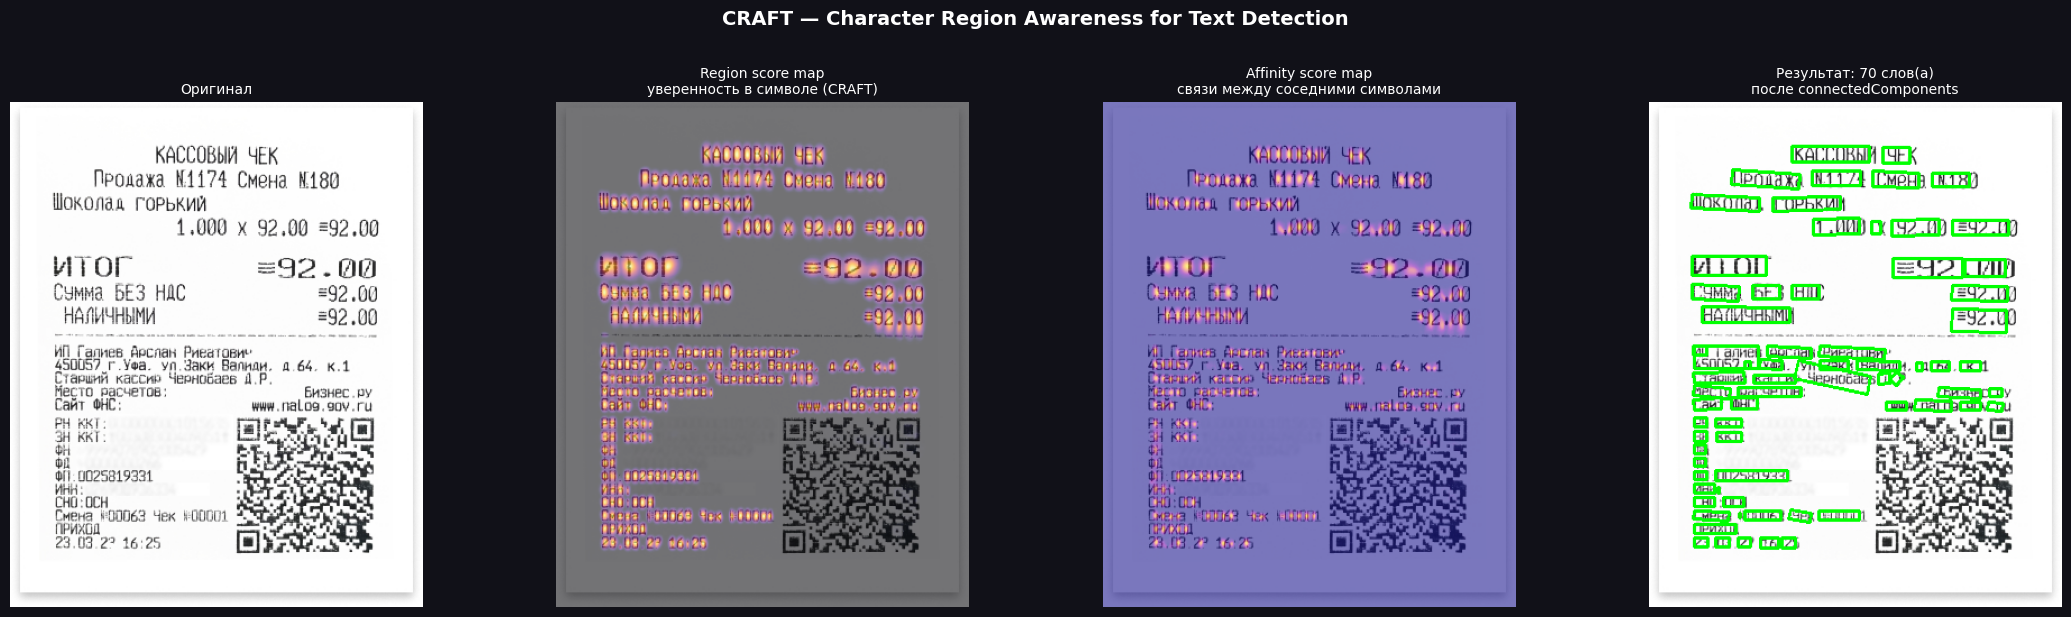

✓  Сохранено: craft_result.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from scipy.ndimage import label

# Чекпоинт хранит decoder как upconv1.conv.0.weight, upconv1.conv.1.weight и т.д.
# Поэтому Sequential должен быть завёрнут в атрибут .conv
class DoubleConv(nn.Module):
    def __init__(self, in_ch, mid_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + mid_ch, mid_ch, 1),
            nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

# VGG16-BN backbone
# Ключи чекпоинта: basenet.slice1.*, basenet.slice2.*, basenet.slice3.*, basenet.slice4.*
# Индексы взяты из оригинального репо clovaai/CRAFT-pytorch: craft.py
class VGG16BN(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision.models import vgg16_bn
        vgg = vgg16_bn(weights=None).features
        self.slice1 = vgg[:12]
        self.slice2 = vgg[12:19]
        self.slice3 = vgg[19:29]
        self.slice4 = vgg[29:39]
        self.slice5 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            nn.Conv2d(512, 1024, 3, padding=6, dilation=6),  # slice5.1
            nn.Conv2d(1024, 1024, 1),                         # slice5.2
        )

    def forward(self, x):
        h1 = self.slice1(x)
        h2 = self.slice2(h1)
        h3 = self.slice3(h2)
        h4 = self.slice4(h3)
        h5 = self.slice5(h4)
        return h1, h2, h3, h4, h5

class CRAFT(nn.Module):
    def __init__(self):
        super().__init__()
        self.basenet = VGG16BN()

        self.upconv1 = DoubleConv(1024, 512, 256)
        self.upconv2 = DoubleConv( 512, 256, 128)
        self.upconv3 = DoubleConv( 256, 128,  64)
        self.upconv4 = DoubleConv( 128,  64,  32)

        self.conv_cls = nn.Sequential(
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 1),            nn.ReLU(inplace=True),
            nn.Conv2d(16,  2, 1),
        )

    def forward(self, x):
        s1, s2, s3, s4, s5 = self.basenet(x)

        def up(feat, skip):
            return F.interpolate(feat, size=skip.shape[2:],
                                 mode="bilinear", align_corners=False)

        y = self.upconv1(torch.cat([up(s5, s4), s4], dim=1))
        y = self.upconv2(torch.cat([up(y,  s3), s3], dim=1))
        y = self.upconv3(torch.cat([up(y,  s2), s2], dim=1))
        y = self.upconv4(torch.cat([up(y,  s1), s1], dim=1))
        return self.conv_cls(y)


WEIGHTS_URL  = "https://huggingface.co/amitesh863/craft/resolve/main/craft_mlt_25k.pth"
WEIGHTS_PATH = Path("craft_mlt_25k.pth")

if not WEIGHTS_PATH.exists():
    print("Загружаем craft_mlt_25k.pth...")
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = CRAFT().to(device)

state = torch.load(WEIGHTS_PATH, map_location=device)
if "craft" in state:
    state = state["craft"]

# Диагностика: печатаем первые 10 ключей чекпоинта
print("Ключи чекпоинта (первые 15):")
for k in list(state.keys())[:15]:
    print(" ", k)

# Убираем префикс module. если модель сохранялась через DataParallel
state = {k.replace("module.", ""): v for k, v in state.items()}

model.load_state_dict(state, strict=False)

# Проверяем что не загрузилось
model_keys   = set(model.state_dict().keys())
ckpt_keys    = set(state.keys())
missing      = model_keys - ckpt_keys
unexpected   = ckpt_keys  - model_keys
if missing:
    print(f"⚠  Missing ({len(missing)}):")
    for k in sorted(missing): print("   ", k)
if unexpected:
    print(f"⚠  Unexpected ({len(unexpected)}):")
    for k in sorted(unexpected): print("   ", k)
if not missing and not unexpected:
    print("✓  Все ключи совпали")
model.eval()
print("✓  Веса загружены")


#  Препроцессинг
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess(image_bgr: np.ndarray, long_side: int = 1280):
    """
    Масштабируем так чтобы длинная сторона = long_side,
    затем padding до кратного 32.
    """
    h, w = image_bgr.shape[:2]
    scale = long_side / max(h, w)
    new_h = int(h * scale) // 32 * 32
    new_w = int(w * scale) // 32 * 32

    resized = cv2.resize(image_bgr, (new_w, new_h))
    img_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img_norm = (img_rgb - MEAN) / STD                     # нормализация ImageNet
    tensor = torch.from_numpy(img_norm.transpose(2,0,1))  # HWC → CHW
    return tensor.unsqueeze(0).to(device), scale           # (1,3,H,W)

#  Инференс
IMAGE_PATH = "/content/cost_badge_1.jpg"
image_bgr  = cv2.imread(IMAGE_PATH)
assert image_bgr is not None, f"Не удалось загрузить: {IMAGE_PATH}"
orig_h, orig_w = image_bgr.shape[:2]
print(f"Изображение: {orig_w}×{orig_h}")

LONG_SIDE    = 1280
SCORE_THRESH = 0.4   # порог region score для бинаризации
LINK_THRESH  = 0.4   # порог affinity score

tensor, scale = preprocess(image_bgr, LONG_SIDE)

with torch.no_grad():
    out = model(tensor)                         # (1, 2, H/2, W/2)

region_map   = out[0, 0].cpu().numpy()   # вероятность символа,  уже в [0,1]
affinity_map = out[0, 1].cpu().numpy()   # связь между символами, уже в [0,1]


#  Постобработка в боксы
def get_boxes(region_map: np.ndarray, affinity_map: np.ndarray,
              score_thresh: float, link_thresh: float,
              scale: float, orig_w: int, orig_h: int):
    """
    Классическая постобработка CRAFT:
      1. Бинаризуем region map по score_thresh
      2. Бинаризуем affinity map по link_thresh
      3. OR > connectedComponents > один компонент = одно слово
      4. minAreaRect > масштабируем в оригинальное пространство
    """
    map_h, map_w = region_map.shape

    # Карта имеет stride=2 от входного тензора размера (inp_h, inp_w).
    # Входной тензор получен масштабированием оригинала на scale.
    # Итого: координата в карте > оригинал: coord_map * 2 / scale
    ratio = 2.0 / scale

    text_mask = (region_map  > score_thresh).astype(np.uint8)
    link_mask = (affinity_map > link_thresh).astype(np.uint8)
    combined  = np.clip(text_mask + link_mask, 0, 1)

    n_labels, labels = cv2.connectedComponents(combined, connectivity=8)

    boxes = []
    for i in range(1, n_labels):
        ys, xs = np.where(labels == i)
        if len(xs) < 10:
            continue

        conf = float(region_map[ys, xs].mean())
        if conf < score_thresh * 0.6:
            continue

        pts_map = np.stack([xs, ys], axis=1).astype(np.float32)
        rect    = cv2.minAreaRect(pts_map)
        (cx, cy), (rw, rh), angle = rect

        # Масштабируем в пространство оригинального изображения
        cx_orig = cx * ratio
        cy_orig = cy * ratio
        rw_orig = rw * ratio
        rh_orig = rh * ratio

        box_pts = cv2.boxPoints(((cx_orig, cy_orig), (rw_orig, rh_orig), angle))
        boxes.append({"pts": np.int32(box_pts), "score": conf})

    return boxes

detections = get_boxes(region_map, affinity_map,
                       SCORE_THRESH, LINK_THRESH,
                       scale, orig_w, orig_h)
print(f"Найдено регионов: {len(detections)}")

#  Визуализация
def overlay(image_bgr, heatmap, colormap, alpha=0.55):
    """Накладывает тепловую карту на оригинал."""
    u8      = np.uint8(np.clip(heatmap, 0, 1) * 255)
    colored = cv2.applyColorMap(u8, colormap)
    blended = cv2.addWeighted(image_bgr, 1 - alpha, colored, alpha, 0)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

# 1. Оригинал
panel_orig = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# 2. Region map наложена на оригинал
region_up    = cv2.resize(region_map, (orig_w, orig_h))
panel_region = overlay(image_bgr, region_up, cv2.COLORMAP_INFERNO)

# 3. Affinity map наложена на оригинал
affinity_up    = cv2.resize(affinity_map, (orig_w, orig_h))
panel_affinity = overlay(image_bgr, affinity_up, cv2.COLORMAP_PLASMA)

# 4. Финальные боксы
panel_result = image_bgr.copy()
for det in detections:
    score = det["score"]
    color = (0, int(255 * min(score * 2, 1)), int(255 * (1 - min(score * 2, 1))))
    cv2.polylines(panel_result, [det["pts"]], isClosed=True, color=color, thickness=2)
panel_result = cv2.cvtColor(panel_result, cv2.COLOR_BGR2RGB)

# 4. Финальные боксы на оригинале
panel_result = image_bgr.copy()
for det in detections:
    score = det["score"]
    color = (0, int(255 * min(score * 2, 1)), int(255 * (1 - min(score * 2, 1))))
    cv2.polylines(panel_result, [det["pts"]], isClosed=True, color=color, thickness=2)
panel_result = cv2.cvtColor(panel_result, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.patch.set_facecolor("#111118")
fig.suptitle("CRAFT — Character Region Awareness for Text Detection",
             color="white", fontsize=14, fontweight="bold", y=1.02)

panels = [
    (panel_orig,     "Оригинал",          None),
    (panel_region,   "Region score map",  "уверенность в символе (CRAFT)"),
    (panel_affinity, "Affinity score map","связи между соседними символами"),
    (panel_result,   f"Результат: {len(detections)} слов(а)", "после connectedComponents"),
]

for ax, (img, title, subtitle) in zip(axes, panels):
    ax.imshow(img)
    label = f"{title}\n{subtitle}" if subtitle else title
    ax.set_title(label, color="white", fontsize=10, pad=6)
    ax.axis("off")

plt.tight_layout()
plt.savefig("craft_result.png", dpi=150, bbox_inches="tight", facecolor="#111118")
plt.show()
print("✓  Сохранено: craft_result.png")

## DB-Net (Differentiable Binarization Network)

<center><img src ="https://ml.gan4x4.ru/wb/ocr/DBnet.png" width="1000"></center>

<center><em>Source: <a href="https://arxiv.org/abs/1911.08947">Differentiable Binarization Network</a></em></center>

**Интуиция**. Обычно после работы нейросети нам нужно превратить плавную карту вероятностей в четкие границы. Этот процесс называется бинаризацией, и раньше его делали вручную через фиксированный порог: все пиксели с вероятностью выше 0.5 считаются текстом, остальные нет. Проблема в том, что один порог на все изображение плохо работает там, где текст мелкий, размытый или расположен на сложном фоне. Авторы DB-Net решили эту проблему радикально: они встроили бинаризацию прямо внутрь сети и сделали ее обучаемой.


**Архитектура**. Backbone это ResNet-50, который извлекает признаки на четырех масштабах. Neck это FPN: признаки с разных уровней объединяются через lateral connections и конкатенируются в единую карту признаков. Head состоит из двух веток: prob head предсказывает карту вероятностей P, а thresh head предсказывает адаптивную карту порогов T. На инференсе используется только prob head, что делает модель быстрой.

Обычный порог это недифференцируемая операция: производную от функции "больше или меньше 0.5" посчитать нельзя, а значит нельзя обучить сеть через такой блок. Авторы заменили его на плавную аппроксимацию:

$$P_{i,j} = \frac{1}{1 + e^{-k(P_{i,j} - T_{i,j})}}$$

Где $P$ — карта вероятности, $T$ — адаптивная карта порогов, а $k$ — коэффициент усиления. Это позволяет сети самой учиться тому, где проводить границу текста, что делает её невероятно точной на стыках букв.


 При большом $k$ эта формула ведет себя почти как жесткий порог, но при этом остается дифференцируемой и позволяет градиентам течь через нее во время обучения. В результате сеть сама учится где проводить границу текста, причем по-разному для каждого участка изображения.

Оригинальный DB обучается с тремя лоссами одновременно: prob map, thresh map и  итоговая binary map. DB++ добавляет Adaptive Scale Fusion, что улучшает работу с текстом разного масштаба в одном изображении.


**Важный нюанс.** DB-Net выдает не повернутые прямоугольники как EAST, а произвольные полигоны. После бинаризации контуры расширяются через алгоритм unclip: каждый полигон увеличивается пропорционально своей площади и периметру. Это компенсирует то, что во время обучения сеть учится предсказывать слегка уменьшенные контуры вокруг текста, а unclip возвращает их к реальным границам слова.

### Пример работы

Device: cpu
Ключи чекпоинта (первые 8):
  feat_extractor.conv1.weight
  feat_extractor.bn1.weight
  feat_extractor.bn1.bias
  feat_extractor.bn1.running_mean
  feat_extractor.bn1.running_var
  feat_extractor.bn1.num_batches_tracked
  feat_extractor.layer1.0.conv1.weight
  feat_extractor.layer1.0.bn1.weight
Ключи prob_head из чекпоинта:
  prob_head.0.weight  shape=(64, 256, 3, 3)
  prob_head.1.weight  shape=(64,)
  prob_head.1.bias  shape=(64,)
  prob_head.1.running_mean  shape=(64,)
  prob_head.1.running_var  shape=(64,)
  prob_head.1.num_batches_tracked  shape=()
  prob_head.3.weight  shape=(64, 64, 2, 2)
  prob_head.4.weight  shape=(64,)
  prob_head.4.bias  shape=(64,)
  prob_head.4.running_mean  shape=(64,)
  prob_head.4.running_var  shape=(64,)
  prob_head.4.num_batches_tracked  shape=()
  prob_head.6.weight  shape=(64, 1, 2, 2)
  prob_head.6.bias  shape=(1,)
Ключи thresh_head из чекпоинта:
  thresh_head.0.weight  shape=(64, 256, 3, 3)
  thresh_head.1.weight  shape=(64,)
  thresh_h

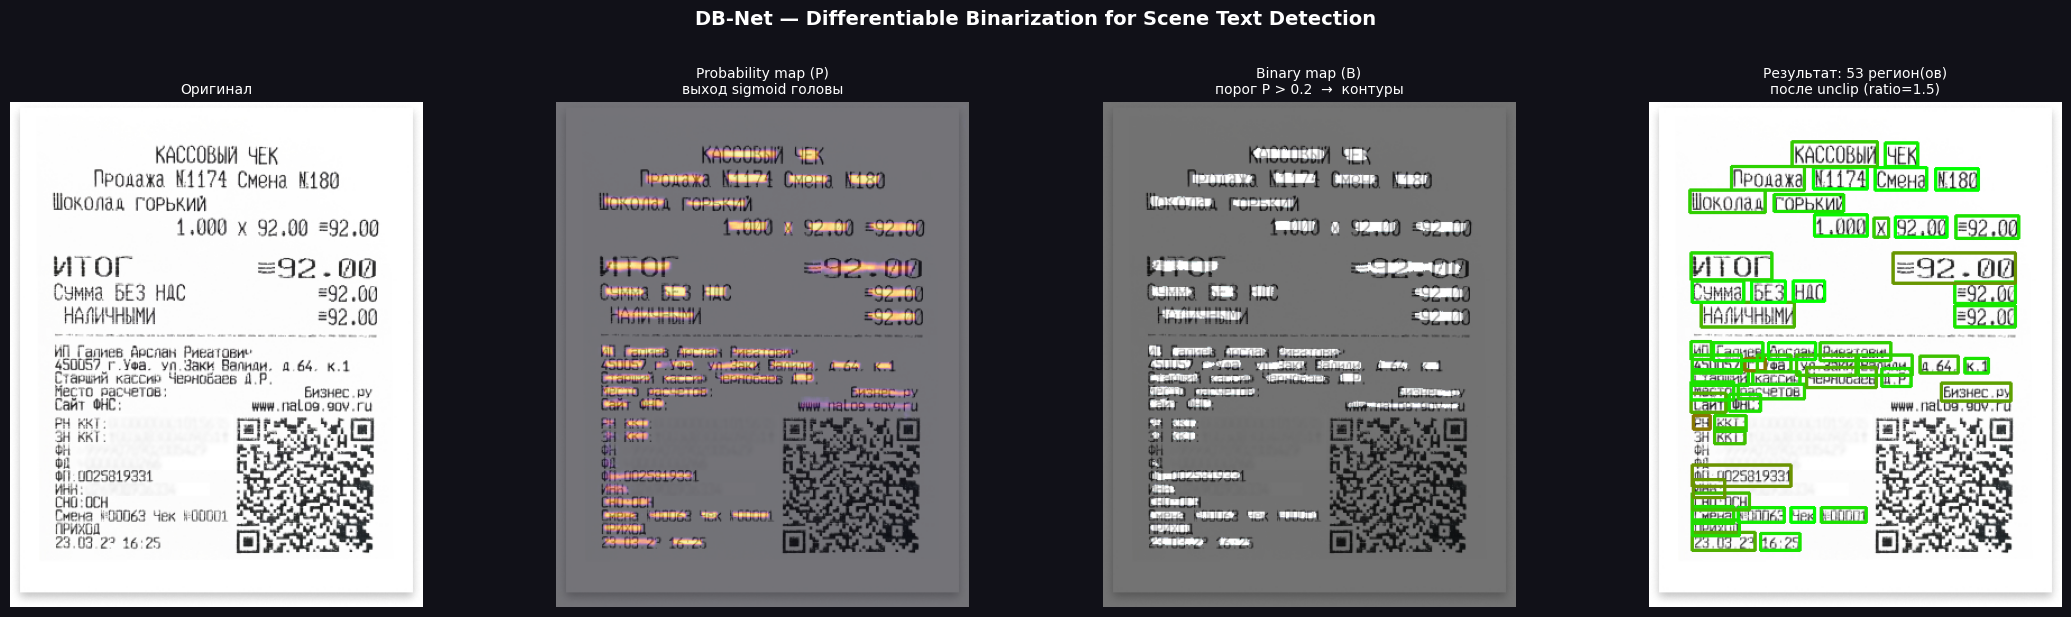

✓  Сохранено: dbnet_result.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torchvision.models import resnet50, ResNet50_Weights


def _lateral_branch(in_ch: int, out_ch: int = 256):
    """in_branches.* — lateral: Conv2d + BN + ReLU (ключи чекпоинта: fpn.in_branches.N.0/1)"""
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

def _output_branch(in_ch: int, out_ch: int = 64):
    """out_branches.* — output: Conv2d + BN + ReLU (ключи чекпоинта: fpn.out_branches.N.0/1)"""
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

class DBFPN(nn.Module):
    """
    FPN doctr-style.
    Ключи чекпоинта:
      fpn.in_branches.{0-3}.*  — lateral 1×1 Conv+BN+ReLU для каждого уровня
      fpn.out_branches.{0-3}.* — output  3×3 Conv+BN+ReLU для каждого уровня
    """
    def __init__(self):
        super().__init__()
        # in_branches[0..3] соответствуют layer1..4 (256, 512, 1024, 2048 каналов)
        self.in_branches = nn.ModuleList([
            _lateral_branch( 256, 256),
            _lateral_branch( 512, 256),
            _lateral_branch(1024, 256),
            _lateral_branch(2048, 256),
        ])
        # out_branches[0..3] — выходные свёртки (256→64)
        self.out_branches = nn.ModuleList([
            _output_branch(256, 64),
            _output_branch(256, 64),
            _output_branch(256, 64),
            _output_branch(256, 64),
        ])

    def forward(self, c2, c3, c4, c5):
        # Lateral projections
        p2 = self.in_branches[0](c2)
        p3 = self.in_branches[1](c3)
        p4 = self.in_branches[2](c4)
        p5 = self.in_branches[3](c5)

        # Top-down merge
        p4 = p4 + F.interpolate(p5, size=p4.shape[2:], mode='nearest')
        p3 = p3 + F.interpolate(p4, size=p3.shape[2:], mode='nearest')
        p2 = p2 + F.interpolate(p3, size=p2.shape[2:], mode='nearest')

        # Output branches + upsample все до размера p2 и concat
        s = p2.shape[2:]
        fused = torch.cat([
            self.out_branches[0](p2),
            F.interpolate(self.out_branches[1](p3), size=s, mode='nearest'),
            F.interpolate(self.out_branches[2](p4), size=s, mode='nearest'),
            F.interpolate(self.out_branches[3](p5), size=s, mode='nearest'),
        ], dim=1)   # (B, 256, H/4, W/4)
        return fused


def _head_branch(in_ch: int = 256):
    """
    Голова DB-Net: Conv→BN→ReLU → ConvTranspose×2.
    Ключи чекпоинта: prob_head.0/1/2/3/4/5/6, thresh_head.*
    Missing только .3.bias — это bias ConvTranspose, в doctr он отключён (bias=False).
    """
    return nn.Sequential(
        nn.Conv2d(in_ch, in_ch // 4, 3, padding=1, bias=False),   # 0
        nn.BatchNorm2d(in_ch // 4),                                 # 1
        nn.ReLU(inplace=True),                                      # 2
        nn.ConvTranspose2d(in_ch // 4, in_ch // 4, 2, stride=2, bias=False),  # 3
        nn.BatchNorm2d(in_ch // 4),                                 # 4
        nn.ReLU(inplace=True),                                      # 5
        nn.ConvTranspose2d(in_ch // 4, 1, 2, stride=2),            # 6
    )


class DBNet(nn.Module):
    """
    DB-Net: ResNet-50 + FPN + DB head.
    Ключи чекпоинта (doctr v0.4.1):
      feat_extractor.conv1 / bn1 / layer1..4
      fpn.in_branches.* / fpn.out_branches.*
      prob_head.* / thresh_head.*
    """
    def __init__(self):
        super().__init__()
        bb = resnet50(weights=None)
        # feat_extractor хранит ResNet с именованными атрибутами
        class FeatExtractor(nn.Module):
            def __init__(self):
                super().__init__()
                self.conv1   = bb.conv1
                self.bn1     = bb.bn1
                self.relu    = bb.relu
                self.maxpool = bb.maxpool
                self.layer1  = bb.layer1   # → 256ch, stride 4
                self.layer2  = bb.layer2   # → 512ch, stride 8
                self.layer3  = bb.layer3   # → 1024ch, stride 16
                self.layer4  = bb.layer4   # → 2048ch, stride 32

            def forward(self, x):
                x  = self.maxpool(self.relu(self.bn1(self.conv1(x))))
                c2 = self.layer1(x)
                c3 = self.layer2(c2)
                c4 = self.layer3(c3)
                c5 = self.layer4(c4)
                return c2, c3, c4, c5

        self.feat_extractor = FeatExtractor()
        self.fpn             = DBFPN()
        self.prob_head       = _head_branch(256)
        self.thresh_head     = _head_branch(256)   # нужен только для загрузки весов

    def forward(self, x):
        c2, c3, c4, c5 = self.feat_extractor(x)
        fused    = self.fpn(c2, c3, c4, c5)              # (B, 256, H/4, W/4)
        prob_map = torch.sigmoid(self.prob_head(fused))   # (B, 1, H, W)
        return prob_map

#  Загрузка весов (doctr pretrained, ICDAR 2015)

WEIGHTS_URL  = "https://doctr-static.mindee.com/models?id=v0.4.1/db_resnet50-1138863a.pt&src=0"
WEIGHTS_PATH = Path("db_resnet50.pt")

if not WEIGHTS_PATH.exists():
    print("⬇  Загружаем DB-Net weights (~100 MB)...")
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = DBNet().to(device)

state = torch.load(WEIGHTS_PATH, map_location=device)

# Диагностика ключей
print("Ключи чекпоинта (первые 8):")
for k in list(state.keys())[:8]:
    print(" ", k)

state = {k.replace("module.", ""): v for k, v in state.items()}

print("Ключи prob_head из чекпоинта:")
for k, v in state.items():
    if "prob_head" in k:
        print(f"  {k}  shape={tuple(v.shape)}")
print("Ключи thresh_head из чекпоинта:")
for k, v in state.items():
    if "thresh_head" in k:
        print(f"  {k}  shape={tuple(v.shape)}")
missing, unexpected = model.load_state_dict(state, strict=False)
if missing:
    print(f"⚠  Missing ({len(missing)}):"); [print("   ", k) for k in sorted(missing)]
if unexpected:
    print(f"⚠  Unexpected ({len(unexpected)}):"); [print("   ", k) for k in sorted(unexpected)]
if not missing and not unexpected:
    print(" Все ключи совпали")

model.eval()
print("Модель загружена")

#  Препроцессинг
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess(image_bgr: np.ndarray, long_side: int = 1024):
    """Масштабируем по длинной стороне, кратно 32, нормализуем ImageNet."""
    h, w = image_bgr.shape[:2]
    scale = long_side / max(h, w)
    new_h = max(32, int(h * scale) // 32 * 32)
    new_w = max(32, int(w * scale) // 32 * 32)

    resized  = cv2.resize(image_bgr, (new_w, new_h))
    img_rgb  = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img_norm = (img_rgb - MEAN) / STD
    tensor   = torch.from_numpy(img_norm.transpose(2, 0, 1)).unsqueeze(0).to(device)
    return tensor, scale

#  Инференс
IMAGE_PATH = "/content/cost_badge_1.jpg"
image_bgr  = cv2.imread(IMAGE_PATH)
assert image_bgr is not None, f"Не удалось загрузить: {IMAGE_PATH}"
orig_h, orig_w = image_bgr.shape[:2]
print(f"Изображение: {orig_w}×{orig_h}")

LONG_SIDE    = 1024
PROB_THRESH  = 0.2   # порог бинаризации prob map (было 0.3)
BOX_THRESH   = 0.3   # минимальный средний score контура (было 0.5)
UNCLIP_RATIO = 1.5   # расширение контура

tensor, scale = preprocess(image_bgr, LONG_SIDE)

with torch.no_grad():
    prob_map = model(tensor)[0, 0].cpu().numpy()   # (H, W)

print(f"Входной тензор: {tuple(tensor.shape)}")
print(f"prob_map shape: {prob_map.shape}")
print(f"Ожидаемый размер оригинала: {orig_h}×{orig_w}")
print(f"scale={scale:.4f} → ввод был {int(orig_h*scale)}×{int(orig_w*scale)}")

#  Постобработка — DB unclip algorithm
#  В отличие от CRAFT/EAST здесь нет connectedComponents на feature map —
#  бинаризуем prob_map и находим контуры напрямую, затем расширяем через Polygon offset

def get_boxes(prob_map: np.ndarray, scale: float, orig_w: int, orig_h: int,
              prob_thresh: float, box_thresh: float, unclip_ratio: float):
    """
    DB постобработка (упрощённая, надёжная):
      1. Бинаризуем prob_map
      2. findContours
      3. Фильтр по среднему prob (box_thresh)
      4. boundingRect → axis-aligned бокс (без угловых артефактов minAreaRect)
      5. Unclip: расширяем бокс на offset = area*ratio/perimeter
      6. Масштабируем в оригинал
    """
    binary = (prob_map > prob_thresh).astype(np.uint8) * 255
    contours, _ = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    # prob_map имеет тот же размер что входной тензор (два ConvTranspose stride=2
    # компенсируют stride=4 backbone). ratio = оригинал / карта — без scale.
    ratio_w = orig_w / prob_map.shape[1]
    ratio_h = orig_h / prob_map.shape[0]

    boxes = []
    for cnt in contours:
        if len(cnt) < 4:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        if min(w, h) < 4:
            continue

        # confidence — средний prob внутри бокса
        roi  = prob_map[y:y+h, x:x+w]
        conf = float(roi.mean())
        if conf < box_thresh:
            continue

        # Unclip: вычисляем offset и расширяем бокс равномерно
        area   = w * h
        peri   = 2 * (w + h)
        offset = int(area * unclip_ratio / peri)

        x1 = max(0, x - offset)
        y1 = max(0, y - offset)
        x2 = min(prob_map.shape[1], x + w + offset)
        y2 = min(prob_map.shape[0], y + h + offset)

        # 4 угла → масштаб в оригинал
        pts = np.array([
            [x1 * ratio_w, y1 * ratio_h],
            [x2 * ratio_w, y1 * ratio_h],
            [x2 * ratio_w, y2 * ratio_h],
            [x1 * ratio_w, y2 * ratio_h],
        ], dtype=np.int32)

        boxes.append({"pts": pts, "score": conf})

    return boxes


detections = get_boxes(prob_map, scale, orig_w, orig_h,
                       PROB_THRESH, BOX_THRESH, UNCLIP_RATIO)
print(f"Найдено регионов: {len(detections)}")

#  Визуализация
def overlay(image_bgr, heatmap, colormap, alpha=0.55):
    """Накладывает тепловую карту на оригинал."""
    u8      = np.uint8(np.clip(heatmap, 0, 1) * 255)
    colored = cv2.applyColorMap(u8, colormap)
    blended = cv2.addWeighted(image_bgr, 1 - alpha, colored, alpha, 0)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

# 1. Оригинал
panel_orig = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# 2. Prob map overlay
prob_up      = cv2.resize(prob_map, (orig_w, orig_h))
panel_prob   = overlay(image_bgr, prob_up, cv2.COLORMAP_INFERNO)

# 3. Binary map overlay
binary_up    = cv2.resize((prob_map > PROB_THRESH).astype(np.float32), (orig_w, orig_h))
panel_binary = overlay(image_bgr, binary_up, cv2.COLORMAP_BONE)

# 4. Финальные боксы
panel_result = image_bgr.copy()
for det in detections:
    score = det["score"]
    color = (0, int(255 * min(score * 1.5, 1.0)), int(255 * (1 - min(score * 1.5, 1.0))))
    cv2.polylines(panel_result, [det["pts"]], isClosed=True, color=color, thickness=2)
panel_result = cv2.cvtColor(panel_result, cv2.COLOR_BGR2RGB)

# 4. Финальные боксы
panel_result = image_bgr.copy()
for det in detections:
    score = det["score"]
    color = (0, int(255 * min(score * 1.5, 1.0)), int(255 * (1 - min(score * 1.5, 1.0))))
    cv2.polylines(panel_result, [det["pts"]], isClosed=True, color=color, thickness=2)
panel_result = cv2.cvtColor(panel_result, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.patch.set_facecolor("#111118")
fig.suptitle("DB-Net — Differentiable Binarization for Scene Text Detection",
             color="white", fontsize=14, fontweight="bold", y=1.02)

panels = [
    (panel_orig,   "Оригинал",                None),
    (panel_prob,   "Probability map (P)",     "выход sigmoid головы"),
    (panel_binary, f"Binary map (B)",         f"порог P > {PROB_THRESH}  →  контуры"),
    (panel_result, f"Результат: {len(detections)} регион(ов)", f"после unclip (ratio={UNCLIP_RATIO})"),
]

for ax, (img, title, subtitle) in zip(axes, panels):
    ax.imshow(img)
    label = f"{title}\n{subtitle}" if subtitle else title
    ax.set_title(label, color="white", fontsize=10, pad=6)
    ax.axis("off")

plt.tight_layout()
plt.savefig("dbnet_result.png", dpi=150, bbox_inches="tight", facecolor="#111118")
plt.show()
print("✓  Сохранено: dbnet_result.png")

# Датасеты

Для того, чтобы лучше понять контекст работы моделей стоит посмотреть на каких датасетах они обучались:

* **EAST** —  ICDAR 2015, COCO-Text

* **CRAFT** — SynthText, ICDAR

* **DB-Net** — CTW1500, Total-Text

Посмотрим ниже на примеры

## SynthText

 Огромный набор искусственно сгенерированных изображений (около 800 000 изображений). Текст накладывается на обычные фото с учетом глубины сцены (чтобы он не "висел" в воздухе). Без него CRAFT не смог бы научиться находить отдельные символы, так как на реальных фото размечать каждую букву слишком дорого.

<center><img src ="https://ml.gan4x4.ru/wb/ocr/sunthtext.png" width="700"></center>

## ICDAR

Популярный датасет, ориентированный на текст, снятый "на ходу" (носимыми камерами) с искажениями перспективы

<center><img src ="https://ml.gan4x4.ru/wb/ocr/icdar_rec.png" width="700"></center>

## COCO-Text

Масштабный набор данных, построенный на базе изображений MS COCO, содержит как печатный, так и рукописный текст. Это проверка на «масштабируемость». Здесь много очень мелкого текста на фоне сложных городских пейзажей. Если модель хорошо работает на COCO-Text, значит, она не будет ошибаться на мусорных баках или кирпичных стенах.

<center><img src ="https://ml.gan4x4.ru/wb/ocr/coco_text.png" width="700"></center>

## CTW1500

Набор данных, специально созданный для детектирования текста сложной формы (изогнутого), содержит 1500 изображений

<center><img src ="https://ml.gan4x4.ru/wb/ocr/CTW1500.jpg" width="700"></center>

## Total-Text

Датасет из 1555 изображений, который стал пионером в предоставлении большого количества криволинейного (curved) текста вместе с горизонтальным и разнонаправленным

<center><img src ="https://ml.gan4x4.ru/wb/ocr/total_text.png" width="700"></center>

# Связь с фреймворками OCR

Мы разобрали три архитектуры EAST, CRAFT и DB-Net не случайно. Именно они лежат в основе тех инструментов, которые вы будете использовать в реальных проектах.


Tesseract v4+ не использует внешние CNN-backbone для детекции вообще. Вместо этого там LSTM, обученный на строках текста, а сегментация делается классическими методами компьютерного зрения. Это объясняет почему Tesseract хорошо работает на чистых документах и плохо на фотографиях с перспективными искажениями.


OpenCV включает EAST как готовый детектор через cv2.dnn Backbone у него PVANet  или ResNet-50.

EasyOCR использует CRAFT как детектор по умолчанию.

PaddleOCR использует DB-Net или его улучшенную версию DB++. В лёгком режиме (Lite) backbone заменяется на MobileNetV3 ради скорости на мобильных устройствах, в серверном режиме используется ResNet-50


Из этого следует практический вывод: выбор фреймворка это косвенно выбор архитектуры детектора. Понимание того что происходит внутри, позволяет осознанно делать выбор, а не перебирать все подряд.